In [109]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

In [128]:
kappa = 0.1
theta = 0.1
xi = 0.1
rho = 0.5
mu = 0.05

T = 1
N = 100
M = 10
v0 = 0.2
S0 = 5

In [129]:
SV_t = np.zeros(shape=(M+1,N,2))
dt = T/M
R = np.array([[1,0],[rho,np.sqrt(1-rho**2)]])
for i in range(N):
    SV = np.zeros(shape=(M+1,2))
    SV[0,0] = S0
    SV[0,1] = v0
    for t in range(1,M+1):
        dB = np.sqrt(dt)*np.random.normal(0,1,size=2)
        A = np.array([SV[t-1,0],SV[t-1,1]])
        B = np.array([mu*SV[t-1,0],kappa*(theta-SV[t-1,1])])
        C = np.diag(np.array([np.sqrt(SV[t-1,1])*SV[t-1,0],xi*np.sqrt(SV[t-1,1])]))@R
        SV[t,:] = A+B*dt+C@dB

    SV_t[:,i,:] = SV

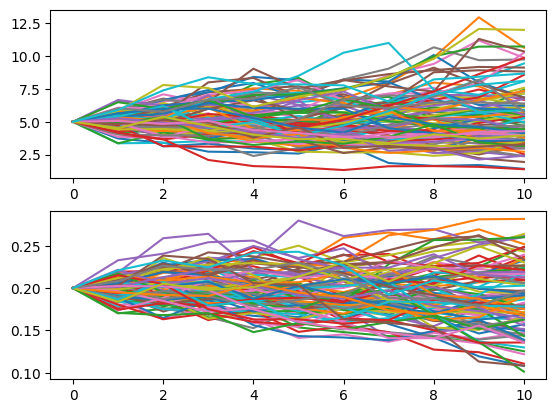

In [130]:
plt.subplot(2,1,1)
plt.plot(SV_t[:,:,0])
plt.subplot(2,1,2)
plt.plot(SV_t[:,:,1])
plt.show()

In [131]:
eta = 1e-3 # learning rate

In [140]:
models = []
opts = []

for j in range(M):
    m = (nn.Sequential(
        nn.Linear(j+1,16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16,1)
    ).double())
    models.append(m)
    opts.append(torch.optim.SGD(m.parameters(),lr=eta))

In [141]:
print(models[0])

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


In [142]:
dt = T/M
epochs = 100
batchsize = int(N/10)
x0=0.5
loss = nn.MSELoss()
def g(s,K):
    return torch.tensor([np.maximum(s-K,0)],dtype=torch.float64)
lam = 1e-5
K =7
loss_evo = []

In [143]:
for e in range(1,epochs):
    order = torch.randperm(N)
    loss_evo_b = []
    for b in range(0,N,batchsize):
        for opt in opts:
            opt.zero_grad()


        L = 0
        for i in order[b:b+batchsize]:
            W = [torch.tensor([x0],dtype=torch.float64)]
            for j in range(1,M+1):
                if j > 1:
                    I = torch.from_numpy(SV_t[0:j,i,0]) # only the price
                elif j == 1:
                    I = torch.tensor([SV_t[j-1,i,0]])
                alpha = models[j-1](I)
                W_ = W[-1]+alpha*(SV_t[j,i,0]-SV_t[j-1,i,0])
                W.append(W_)
            L = L + loss(g(SV_t[-1,i,0],K),W_) 


        weight = []
        for j in range(M):
            theta = torch.nn.utils.parameters_to_vector(models[j].parameters())
            weight.append(torch.norm(theta,p=2)**2)

        L = L/batchsize +  lam * sum(weight)
        loss_evo_b.append(L.detach())
        L.backward()
        for opt in opts:
            opt.step()

    loss_evo.append(np.mean(loss_evo_b))

    if e%10 == 0:
        print(f"Epoch:{e}, Loss:{loss_evo[e-1]}")

    

Epoch:10, Loss:0.3588621493986869
Epoch:20, Loss:0.28817907688004624
Epoch:30, Loss:0.2747098041957351
Epoch:40, Loss:0.2677019495526625
Epoch:50, Loss:0.257896921857831
Epoch:60, Loss:0.2524087937890701
Epoch:70, Loss:0.2467025380923788
Epoch:80, Loss:0.23973106619355833
Epoch:90, Loss:0.23335474159367667


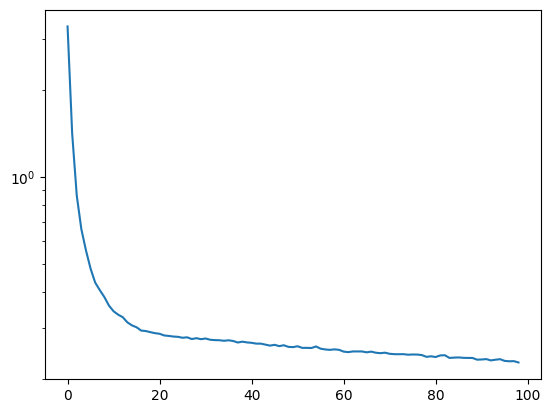

In [144]:
plt.plot(loss_evo)
plt.yscale("log")
plt.show()